Step 1 - Import Required Libraries and Dependencies.
         Load all Python libraries required for data manipulation,              
         visualization, preprocessing, model training, and performance evaluation.

In [1]:
# Step 1: Import Required Libraries and Dependencies

import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Preprocessing
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split

# Metrics
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report
)

# Models
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import (
    BaggingClassifier,
    RandomForestClassifier,
    GradientBoostingClassifier
)


Step 2 - Load and Verify Dataset Files.
         Import training, testing, and sample submission datasets into          
         DataFrames and confirm successful loading.

In [2]:
# Step 2: Load and Verify Dataset Files

train = pd.read_csv("train.csv")
test = pd.read_csv("test.csv")
submission = pd.read_csv("sample_submission.csv")

print(train.shape)
print(test.shape)

train.head()


(20758, 18)
(13840, 17)


,id,Gender,Age,Height,Weight,family_history_with_overweight,FAVC,FCVC,NCP,CAEC,SMOKE,CH2O,SCC,FAF,TUE,CALC,MTRANS,NObeyesdad
0,0,Male,24.443011,1.699998,81.669950,yes,yes,2.000000,2.983297,Sometimes,no,2.763573,no,0.000000,0.976473,Sometimes,Public_Transportation,Overweight_Level_II
1,1,Female,18.000000,1.560000,57.000000,yes,yes,2.000000,3.000000,Frequently,no,2.000000,no,1.000000,1.000000,no,Automobile,Normal_Weight
2,2,Female,18.000000,1.711460,50.165754,yes,yes,1.880534,1.411685,Sometimes,no,1.910378,no,0.866045,1.673584,no,Public_Transportation,Insufficient_Weight
3,3,Female,20.952737,1.710730,131.274851,yes,yes,3.000000,3.000000,Sometimes,no,1.674061,no,1.467863,0.780199,Sometimes,Public_Transportation,Obesity_Type_III
4,4,Male,31.641081,1.914186,93.798055,yes,yes,2.679664,1.971472,Sometimes,no,1.979848,no,1.967973,0.931721,Sometimes,Public_Transportation,Overweight_Level_II


Step3 -  Exploratory Data Analysis (EDA) and Dataset Inspection.
         Examine dataset dimensions, feature types, summary                    
         statistics, and overall data quality before modeling..

In [3]:
# Step 3: Exploratory Data Analysis (EDA) and Dataset Inspection

train.info()
train.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20758 entries, 0 to 20757
Data columns (total 18 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   id                              20758 non-null  int64  
 1   Gender                          20758 non-null  object 
 2   Age                             20758 non-null  float64
 3   Height                          20758 non-null  float64
 4   Weight                          20758 non-null  float64
 5   family_history_with_overweight  20758 non-null  object 
 6   FAVC                            20758 non-null  object 
 7   FCVC                            20758 non-null  float64
 8   NCP                             20758 non-null  float64
 9   CAEC                            20758 non-null  object 
 10  SMOKE                           20758 non-null  object 
 11  CH2O                            20758 non-null  float64
 12  SCC                             

,id,Age,Height,Weight,FCVC,NCP,CH2O,FAF,TUE
count,20758.00000,20758.000000,20758.000000,20758.000000,20758.000000,20758.000000,20758.000000,20758.000000,20758.000000
mean,10378.50000,23.841804,1.700245,87.887768,2.445908,2.761332,2.029418,0.981747,0.616756
std,5992.46278,5.688072,0.087312,26.379443,0.533218,0.705375,0.608467,0.838302,0.602113
min,0.00000,14.000000,1.450000,39.000000,1.000000,1.000000,1.000000,0.000000,0.000000
25%,5189.25000,20.000000,1.631856,66.000000,2.000000,3.000000,1.792022,0.008013,0.000000
50%,10378.50000,22.815416,1.700000,84.064875,2.393837,3.000000,2.000000,1.000000,0.573887
75%,15567.75000,26.000000,1.762887,111.600553,3.000000,3.000000,2.549617,1.587406,1.000000
max,20757.00000,61.000000,1.975663,165.057269,3.000000,4.000000,3.000000,3.000000,2.000000


Step 4 - Correlation Analysis of Numerical Features.
         Analyze relationships among numerical variables to identify            
         important feature interactions and predictive patterns.

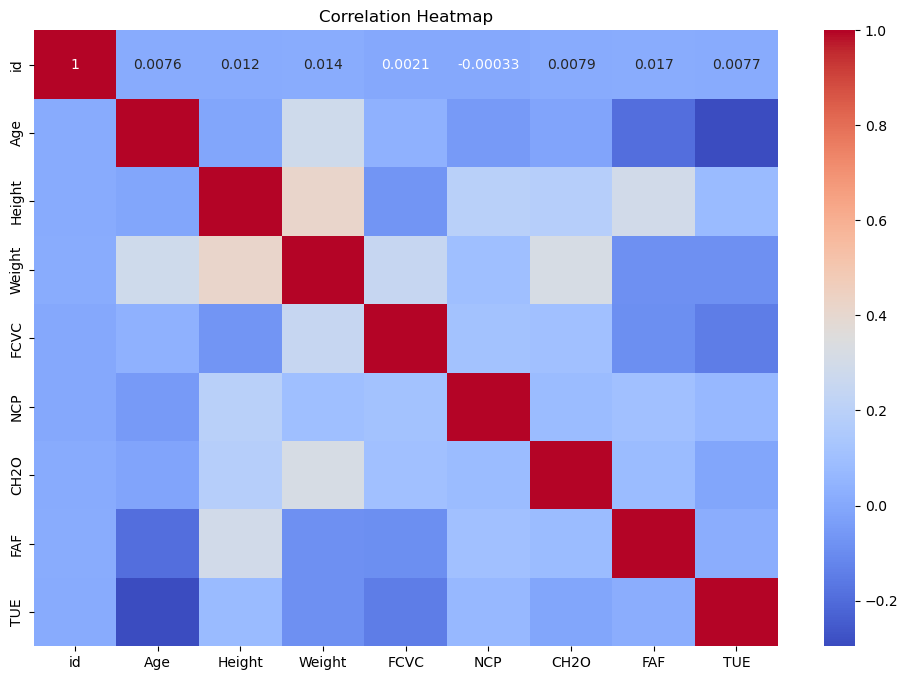

In [4]:
# Step 4 Correlation Analysis of Numerical Features

plt.figure(figsize=(12,8))
sns.heatmap(train.corr(numeric_only=True),
cmap='coolwarm',
annot=True)
plt.title("Correlation Heatmap")

plt.savefig("Obesity-Risk-Classification-Ensemble-Models/MODEL 4_GRADIENT BOOSTING SUBMISSION/reports/figures/correlation_heatmap.png", dpi=300, bbox_inches="tight")

plt.show()

Step 5 - Feature Distribution Visualization.
         Explore the distribution of numeric features using histograms          
         to identify trends, skewness, and potential outliers.

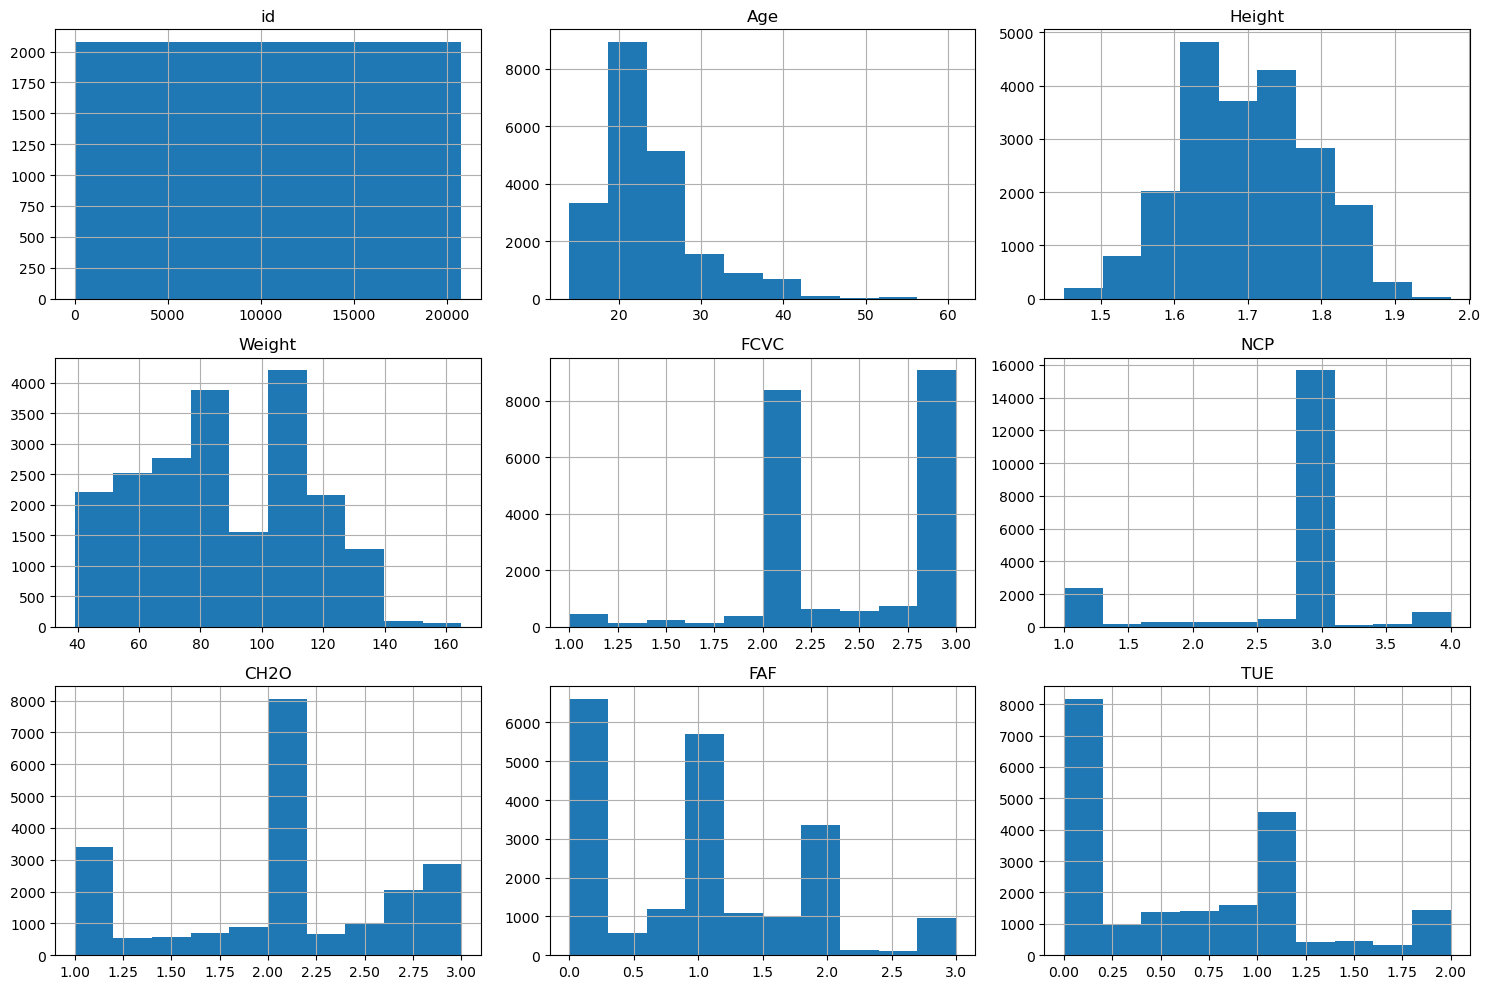

In [5]:
# Step 5: Feature Distribution Visualization

train.hist(figsize=(15,10))
plt.tight_layout()

plt.savefig("Obesity-Risk-Classification-Ensemble-Models/MODEL 4_GRADIENT BOOSTING SUBMISSION/reports/figures/feature_distributions.png", dpi=300, bbox_inches="tight")

plt.show()

Step 6 -  Target Class Distribution Assessment.
          Visualize obesity class frequencies to evaluate class                 
          balance before training the model..

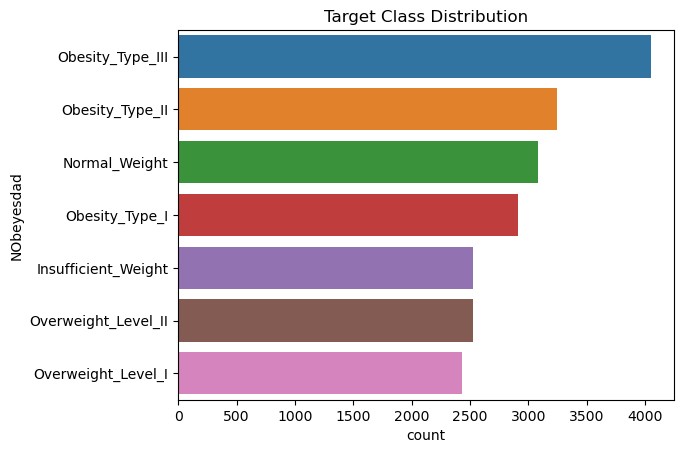

In [6]:
# Step 6: Target Class Distribution Assessment

sns.countplot(
    y='NObeyesdad',
    data=train,
    order=train['NObeyesdad'].value_counts().index
)

plt.title("Target Class Distribution")

plt.savefig("Obesity-Risk-Classification-Ensemble-Models/MODEL 4_GRADIENT BOOSTING SUBMISSION/reports/figures/target_class_distribution.png", dpi=300, bbox_inches="tight")

plt.show()


Step 7 -  Categorical Encoding and Feature Engineering Preparation.
          Convert categorical variables into machine-readable                   
          numerical values and separate predictors from the target variable.

In [7]:
# Step 7: Categorical Encoding and Feature Engineering Preparation

combined = pd.concat([train.drop("NObeyesdad", axis=1), test])

categorical_cols = combined.select_dtypes(include=["object"]).columns

encoders = {}

for col in categorical_cols:
    le = LabelEncoder()
    combined[col] = le.fit_transform(combined[col])
    encoders[col] = le

X_train_full = combined.iloc[:len(train)]
X_test = combined.iloc[len(train):]

target_encoder = LabelEncoder()

y = target_encoder.fit_transform(train["NObeyesdad"])


Step 8 - Train–Validation Data Splitting.
         Partition the dataset into training and validation sets to            
         enable unbiased model evaluation.

In [8]:
# Step 8: Train–Validation Data Splitting

from sklearn.model_selection import train_test_split

# Split the encoded full training matrix into train/validation sets
X_train, X_valid, y_train, y_valid = train_test_split(
    X_train_full,      # all encoded features
    y,                 # encoded target labels
    test_size=0.20,    # 20% validation
    random_state=42,   # reproducibility
    stratify=y         # keeps class distribution balanced
)

print("Training set shape:", X_train.shape)
print("Validation set shape:", X_valid.shape)
print("Training labels:", y_train.shape)
print("Validation labels:", y_valid.shape)


Training set shape: (16606, 17)
Validation set shape: (4152, 17)
Training labels: (16606,)
Validation labels: (4152,)


Step 9 -  Gradient Boosting Model Training.
          Train the Gradient Boosting Classifier using optimized                 
          hyperparameters to learn complex feature relationships.

In [9]:
# Step 9: Gradient Boosting Model Training

gb_model = GradientBoostingClassifier(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=5,
    random_state=42
)

gb_model.fit(X_train, y_train)


GradientBoostingClassifier(learning_rate=0.05, max_depth=5, n_estimators=300,
                           random_state=42)

Step 10 -  Model Validation and Performance Evaluation.
           Generate predictions on validation data and measure                    
           predictive performance using accuracy and classification metrics.

In [10]:
# Step 10: Model Validation and Performance Evaluation

# Predict on the validation set
gb_preds = gb_model.predict(X_valid)

# Compute accuracy
val_accuracy = accuracy_score(y_valid, gb_preds)
print("Validation Accuracy:", val_accuracy)

# Optional: Detailed classification report
print("\nClassification Report:")
print(classification_report(y_valid, gb_preds))

Validation Accuracy: 0.9094412331406551

Classification Report:
              precision    recall  f1-score   support

           0       0.93      0.96      0.95       505
           1       0.89      0.89      0.89       617
           2       0.88      0.90      0.89       582
           3       0.97      0.97      0.97       650
           4       1.00      0.99      1.00       809
           5       0.82      0.77      0.79       485
           6       0.81      0.82      0.81       504

    accuracy                           0.91      4152
   macro avg       0.90      0.90      0.90      4152
weighted avg       0.91      0.91      0.91      4152



Step 11 - Confusion Matrix Performance Analysis.
          Evaluate class-by-class prediction accuracy and identify               
          misclassification patterns

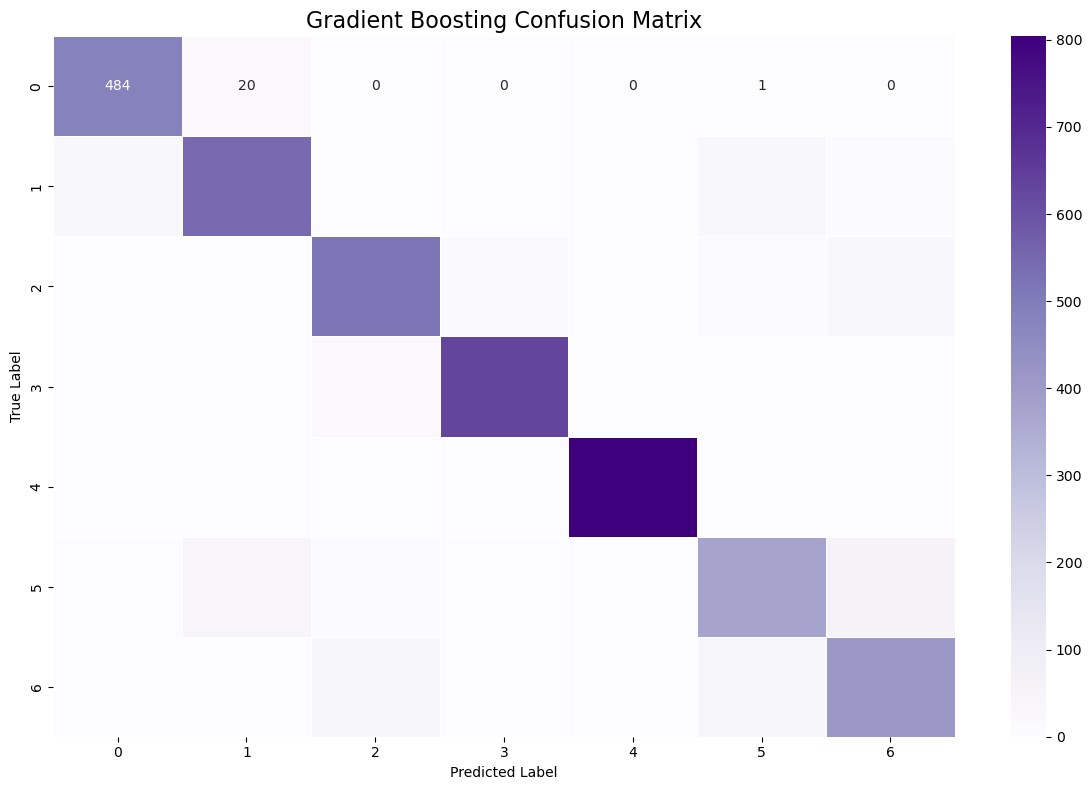

In [11]:
# Step 11: Confusion Matrix Performance Analysis

from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Compute confusion matrix
cm = confusion_matrix(y_valid, gb_preds)

# Plot enhanced confusion matrix
plt.figure(figsize=(12, 8))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Purples',
    linewidths=0.5,
    cbar=True
)

plt.title("Gradient Boosting Confusion Matrix", fontsize=16)
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.tight_layout()

plt.savefig("Obesity-Risk-Classification-Ensemble-Models/MODEL 4_GRADIENT BOOSTING SUBMISSION/reports/figures/gradient_boosting_confusion_matrix.png", dpi=300, bbox_inches="tight")

plt.show()


Step 12 -  Boosting Learning Progress Visualization.
           Monitor validation accuracy throughout the boosting process            
           to assess how performance improves as trees are added.

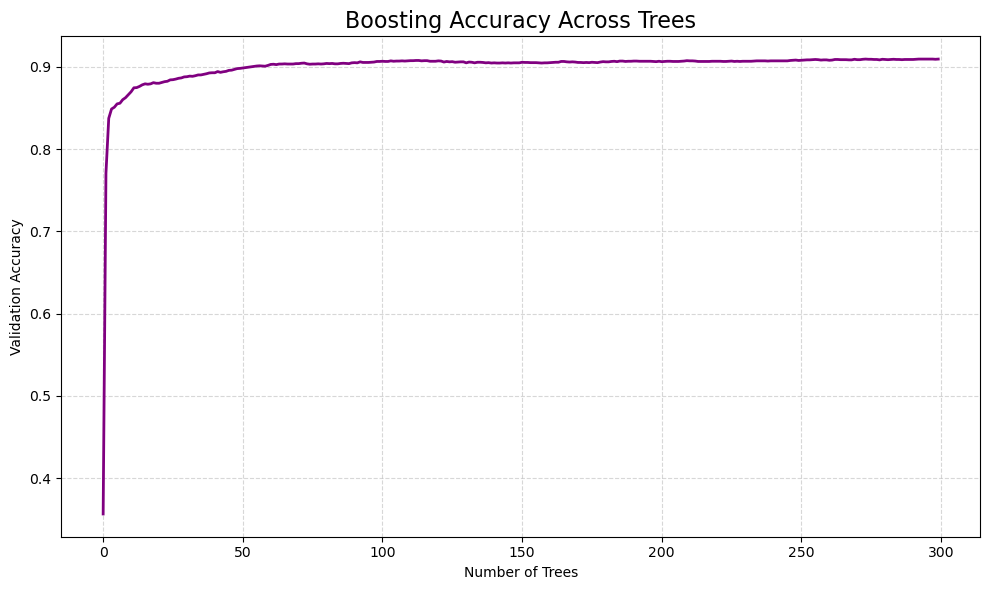

In [12]:
# Step 12: Boosting Learning Progress Visualization

import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score

# Array to store accuracy at each boosting stage
test_score = np.zeros(gb_model.n_estimators, dtype=np.float64)

# Evaluate model performance after each tree is added
for i, pred in enumerate(gb_model.staged_predict(X_valid)):
    test_score[i] = accuracy_score(y_valid, pred)

# Plot training progress
plt.figure(figsize=(10, 6))
plt.plot(test_score, color='purple', linewidth=2)
plt.title("Boosting Accuracy Across Trees", fontsize=16)
plt.xlabel("Number of Trees")
plt.ylabel("Validation Accuracy")
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()

plt.savefig("Obesity-Risk-Classification-Ensemble-Models/MODEL 4_GRADIENT BOOSTING SUBMISSION/reports/figures/boosting_accuracy_across_trees.png", dpi=300, bbox_inches="tight")

plt.show()


Step 13 -  Feature Importance Analysis.
           Identify and rank the most influential predictors                      
           contributing to Gradient Boosting model decisions.

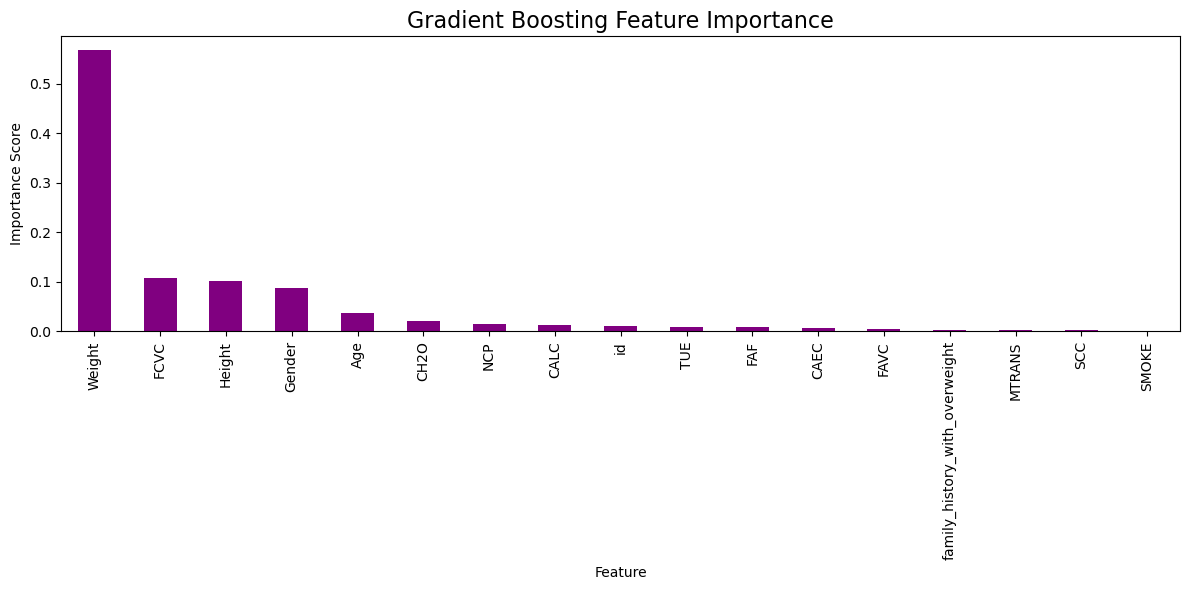

In [13]:
# Step 13: Feature Importance Analysis

import pandas as pd
import matplotlib.pyplot as plt

# Extract feature importance values
feature_importances = pd.Series(
    gb_model.feature_importances_,
    index=X_train.columns
).sort_values(ascending=False)

# Plot top 20 most important features
plt.figure(figsize=(12, 6))
feature_importances.head(20).plot(kind='bar', color='purple')

plt.title("Gradient Boosting Feature Importance", fontsize=16)
plt.ylabel("Importance Score")
plt.xlabel("Feature")
plt.tight_layout()
plt.show()


Step 14 - Kaggle Submission 4 File Generation
          Generate predictions on unseen test data and create a                 
          competition-ready submission file

In [14]:
# Step 14: Kaggle Submission 4 File Generation

# Generate predictions on the test dataset
gb_test_preds = gb_model.predict(X_test)

# Convert encoded predictions back to original labels
submission['NObeyesdad'] = target_encoder.inverse_transform(gb_test_preds)

# Save submission file
submission.to_csv("submission_gradient_boosting.csv", index=False)

print("Kaggle submission file 'submission_gradient_boosting.csv' created successfully.")


Kaggle submission file 'submission_gradient_boosting.csv' created successfully.
